# Data Engineering Pipeline

This notebook focuses on the data engineering process for building a structured dataset of patents related to hardware technologies. The raw patent data is stored in JSON format and contains information such as the application number, title, abstract, and claims.

The goal of this notebook is to extract relevant fields from multiple patent files, clean and preprocess the text data, and filter patents that are related to hardware technologies. The resulting dataset will be used for further analysis and machine learning tasks in later stages of the project.

**Problem Statement**

Patent databases contain thousands of documents covering multiple domains such as electronics, biotechnology, pharmaceuticals, and mechanical engineering. However, for many research and analysis tasks, it is necessary to focus only on patents related to specific domains.

The objective of this project is to identify and extract patents related to hardware technologies by processing raw patent documents. This involves collecting patent data from JSON files, extracting relevant textual fields, cleaning the data, and filtering patents using domain-specific keywords.

### Step 1 - Importing Required Libraries

In this step, the required Python libraries for data processing and analysis are imported. Libraries such as pandas, json, os, and matplotlib are used for reading data files, manipulating datasets, and performing exploratory analysis.


In [23]:
import pandas as pd
import numpy as np
import json
import os
import re
import string
import re 
from collections import Counter
from tqdm import tqdm
from sklearn.utils import resample
import matplotlib.pyplot as plt
import seaborn as sns
from wordcloud import WordCloud


### Step 2 - Data Collection

The dataset consists of multiple JSON patent files stored in a directory. Each file contains information such as the patent title, abstract, and claims. In this step, the program iterates through all JSON files in the directory and extracts the relevant information needed for analysis. The dataset used in this project consists of multiple JSON files containing patent information. Each file includes important attributes such as:

- Application Number
- Title
- Abstract
- Claims

These files are stored in a directory and are processed sequentially to extract relevant information for the dataset.

In [24]:
csv_file = "patents_2018.csv"

if os.path.exists(csv_file):

    print("Dataset already exists. Loading CSV...")

    df = pd.read_csv(csv_file)

    print("Dataset loaded")
    print(df.shape)

else:

    print("CSV not found. Creating dataset from JSON files...")

    folder = r"C:\Users\jewel\Downloads\hupd_2018\2018"

    data = []

    files = os.listdir(folder)

    for file in tqdm(files):

        if file.endswith(".json"):

            path = os.path.join(folder, file)

            with open(path, "r", encoding="utf-8") as f:

                patent = json.load(f)

                application_number = patent.get("application_number")
                title = patent.get("title", "")
                abstract = patent.get("abstract", "")
                claims = patent.get("claims", "")

                text = title + " " + abstract + " " + claims

                data.append({
                    "application_number": application_number,
                    "title": title,
                    "abstract": abstract,
                    "claims": claims,
                    "text": text
                })

    df = pd.DataFrame(data)

    df.to_csv(csv_file, index=False)

    print("Dataset created")
    print(df.shape)

Dataset already exists. Loading CSV...
Dataset loaded
(31968, 5)


In [25]:
df.head()

,application_number,title,abstract,claims,text
0,13817165,Intelligent Drug and/or Fluid Delivery System ...,"A pharmacodynamic (PD), pharmacokinetic (PK), ...",1. A medication or fluid delivery and control ...,Intelligent Drug and/or Fluid Delivery System ...
1,14111139,ANTISTATIC DEVICE AND ASSOCIATED OPERATING METHOD,An antistatic device for reducing electrostati...,1. Antistatic device for reducing electrostati...,ANTISTATIC DEVICE AND ASSOCIATED OPERATING MET...
2,14112715,APPARATUS AND METHODS FOR ASSESSING THE EFFECT...,A method of assessing the effect of viewing va...,1. A method of assessing the effect of viewing...,APPARATUS AND METHODS FOR ASSESSING THE EFFECT...
3,14764986,"BLACK MATRIX, METHOD FOR MANUFACTURING THE SAM...","The disclosure provides a black matrix, a meth...","1. A black matrix, manufactured by the steps o...","BLACK MATRIX, METHOD FOR MANUFACTURING THE SAM..."
4,14765061,A LIGHTING CONTROL SYSTEM,The invention relates to the field of smart se...,"1. A lighting control system, applied for adju...",A LIGHTING CONTROL SYSTEM The invention relate...


### Step 3 - Data Preprocessing

Raw textual data often contains inconsistencies such as punctuation, uppercase letters, and unnecessary characters. Therefore, preprocessing is required to standardize the dataset.

The preprocessing process includes:

- Converting text to lowercase
- Removing punctuation and special characters
- Eliminating unnecessary whitespace
- Preparing the text data for further analysis

In [26]:
df["text"] = df["text"].str.lower()

df["text"] = df["text"].apply(lambda x: re.sub(r"[^\w\s]", " ", x))

df = df.drop_duplicates(subset="text")

print("After cleaning:", df.shape)


After cleaning: (31959, 5)


### Step 4 - Hardware Keyword Identification and Removal of Non-Hardware Patents

To identify hardware-related patents, a list of hardware-specific keywords is defined. These keywords represent components and concepts commonly used in electronic and embedded systems. Examples of hardware-related keywords include: processor, microcontroller, circuit, transistor, sensor, memory, etc.


Patent datasets often contain records related to biology, pharmaceuticals, and other unrelated fields. To ensure the dataset focuses on hardware technologies, a filtering mechanism is applied. Patents containing biological or pharmaceutical keywords such as: protein, antibody, gene, pharmaceutical are excluded from the dataset.


A filtering function is applied to identify patents that contain relevant hardware keywords.

The filtering logic works as follows:

- If a patent contains biological keywords, it is removed.
- If a patent contains multiple hardware-related keywords, it is classified as a hardware patent.

This ensures that only relevant hardware-related patents remain in the dataset.

In [27]:
hardware_keywords = [
"processor","microprocessor","semiconductor","circuit","transistor",
"sensor","microcontroller","hardware","voltage","current",
"signal","power","controller","chip","integrated circuit",
"fpga","logic","pcb","memory","embedded","analog",
"digital","clock","bus","register","gpio","adc","dac"
]

non_hardware_keywords = [
"antibody","antigen","pyridine","pyrazole","imidazole",
"culture","compound","acid","pharmaceutical","drug",
"protein","peptide","dna","rna","gene","biological"
]


def is_hardware(text):

    text = text.lower()
    if any(re.search(r'\b'+w+r'\b', text) for w in non_hardware_keywords):
        return False

    count = sum(bool(re.search(r'\b'+w+r'\b', text)) for w in hardware_keywords)

    return count >= 2


df = df[df["text"].apply(is_hardware)]

print("After hardware filtering:", df.shape)

After hardware filtering: (9661, 5)


In [28]:
df.head()

,application_number,title,abstract,claims,text
1,14111139,ANTISTATIC DEVICE AND ASSOCIATED OPERATING METHOD,An antistatic device for reducing electrostati...,1. Antistatic device for reducing electrostati...,antistatic device and associated operating met...
4,14765061,A LIGHTING CONTROL SYSTEM,The invention relates to the field of smart se...,"1. A lighting control system, applied for adju...",a lighting control system the invention relate...
11,14897676,TOUCH DISPLAY PANEL AND CONTROL CIRCUIT THEREOF,Provided is a touch control display penal and ...,1. A touch control circuit of a touch display ...,touch display panel and control circuit thereo...
12,14897677,ARRAY SUBSTRATE AND METHOD FOR MANUFACTURING T...,Disclosed are an array substrate and a method ...,1. A method for manufacturing an array substra...,array substrate and method for manufacturing t...
13,14897695,LIQUID CRYSTAL DISPLAY DEVICE IN PERPENDICULAR...,A liquid crystal display device in vertical al...,1. A liquid crystal display device in vertical...,liquid crystal display device in perpendicular...


### Step 5 - Stopword Removal and Patent Text Cleaning

Patent documents often contain many common words that do not contribute meaningful information for machine learning models. These words, known as stopwords, include common English terms such as: a, an, the, and, or, with, is, are, was, were, etc. Removing these words helps reduce noise in the dataset and allows the model to focus on more informative technical terms.

In addition to standard English stopwords, patent documents contain domain-specific boilerplate words that appear frequently but do not contribute to identifying the novelty or technical content of the patent. Examples of such patent-specific stopwords include: claim, claims, wherein, said, according, comprising, plurality, configured, includes, etc.

Furthermore, many generic technical words such as method, device, system, apparatus, data, network, communication, and program are commonly used across different patents but provide limited information for novelty classification. These words are considered patent noise and are also removed during preprocessing.

To address this, a combined stopword list is created by merging three categories:

- Standard English stopwords
- Patent boilerplate stopwords
- Generic patent noise words

A preprocessing function is then applied to each patent document. This function performs the following steps:

- Splits the text into individual words
- Removes all words that appear in the combined stopword list
- Reconstructs the cleaned text

After stopword removal, additional cleaning steps are applied to improve dataset quality:

- Records with missing text values are removed.
- Very short texts (less than 20 characters) are filtered out, as they do not provide sufficient information for classification.

This preprocessing step ensures that the dataset contains meaningful technical terms while eliminating unnecessary noise, improving the effectiveness of downstream machine learning models.

In [29]:

stopwords = set([
'a','an','the','and','or','but','if','while','with','to','of','at','by','for','from',
'up','about','into','over','after','is','are','was','were','be','been','being','have',
'has','had','do','does','did','this','that','these','those','in','on','it','its','as',
'when','how','which','such','their','there','than','then','so','because','can','will',
'just','should','further','each'
])

patent_stopwords = [
"claim","claims","wherein","said","according",
"comprising","comprises","plurality","least",
"first","second","one","configured","includes",
"including","associated","based","using","provided"
]

patent_noise = [
"method","device","system","apparatus","unit","portion",
"configured","comprising","comprises","according",
"data","processing","operation","receiving","determining",
"user","interface","network","communication","computer",
"readable","storage","medium","program"
]

extra_stopwords = [
"one","two","three","four","five",
"each","which","where","more","further",
"time","value","current","set","between","when","according claim"
]

numeric_tokens = [str(i) for i in range(100)]

stopwords.update(extra_stopwords)
stopwords.update(numeric_tokens)
stopwords.update(patent_noise)
stopwords.update(patent_stopwords)



def remove_stopwords(text):
    text = re.sub(r"[^\w\s]", " ", text)
    words = text.lower().split()
    words = [w for w in words if w not in stopwords and not w.isdigit()]
    return " ".join(words)

df["clean_text"] = df["text"].apply(remove_stopwords)

df = df.dropna(subset=["clean_text"])

df = df[df["clean_text"].str.len() > 20]

print("After preprocessing:", df.shape)

After preprocessing: (9661, 6)


In [30]:
df.head()

,application_number,title,abstract,claims,text,clean_text
1,14111139,ANTISTATIC DEVICE AND ASSOCIATED OPERATING METHOD,An antistatic device for reducing electrostati...,1. Antistatic device for reducing electrostati...,antistatic device and associated operating met...,antistatic operating antistatic reducing elect...
4,14765061,A LIGHTING CONTROL SYSTEM,The invention relates to the field of smart se...,"1. A lighting control system, applied for adju...",a lighting control system the invention relate...,lighting control invention relates field smart...
11,14897676,TOUCH DISPLAY PANEL AND CONTROL CIRCUIT THEREOF,Provided is a touch control display penal and ...,1. A touch control circuit of a touch display ...,touch display panel and control circuit thereo...,touch display panel control circuit thereof to...
12,14897677,ARRAY SUBSTRATE AND METHOD FOR MANUFACTURING T...,Disclosed are an array substrate and a method ...,1. A method for manufacturing an array substra...,array substrate and method for manufacturing t...,array substrate manufacturing same disclosed a...
13,14897695,LIQUID CRYSTAL DISPLAY DEVICE IN PERPENDICULAR...,A liquid crystal display device in vertical al...,1. A liquid crystal display device in vertical...,liquid crystal display device in perpendicular...,liquid crystal display perpendicular alignment...


### Step 6 - Novelty Score Computation and Tier Assignment

To estimate the level of innovation present in each patent, a novelty scoring mechanism is implemented. This method assigns a numerical score to each patent document based on the presence of specific keywords that indicate different levels of innovation or originality.

Patent descriptions often contain terms that signal the novelty of the invention. These terms are categorized into different groups depending on the strength of the innovation they represent.

The keyword groups used in this scoring method include:

- **Breakthrough keywords:** breakthrough, revolutionary, unprecedented, pioneer  
- **High novelty keywords:** novel, inventive, unique, innovative, original  
- **Moderate novelty keywords:** new, improved, enhanced, advanced, optimized  
- **Negative novelty indicators:** conventional, prior art, standard, known  

Each category contributes differently to the final novelty score:

- Breakthrough terms receive the **highest weight** since they indicate significant innovation.
- High novelty terms contribute a **moderate positive score**.
- Moderate novelty terms provide a **smaller positive contribution**.
- Negative indicators reduce the score because they refer to existing or conventional technologies.

The scoring process works as follows:

- The patent text is converted to lowercase to ensure consistent keyword matching.
- Each keyword category is searched within the text using regular expressions.
- The frequency of each keyword occurrence is multiplied by its respective weight.
- The weighted scores are added or subtracted to compute the overall novelty score.

In addition to keyword-based scoring, a **lexical diversity component** is included. Lexical diversity measures the ratio of unique words to total words in the document. Patents with a higher variety of technical terms are likely to contain more detailed and innovative descriptions.

The lexical diversity score is calculated by:

- Counting the total number of words in the patent text.
- Computing the ratio of unique words to total words.
- Scaling the score based on document length.

This additional factor helps capture the richness of the technical language used in the patent.

After computing the novelty score for each patent, the patents are categorized into different novelty levels using a tier classification system. This helps organize patents according to their degree of innovation.

The tier classification rules are defined as follows:

- **Tier 3 (Highly Novel Patents):** Patents with a novelty score greater than or equal to 15, indicating strong breakthrough innovation.
- **Tier 2 (Moderately Novel Patents):** Patents with a novelty score between 5 and 14, representing meaningful technological improvements.
- **Tier 1 (Incremental Innovation):** Patents with a novelty score between 1 and 4, indicating minor enhancements to existing technologies.
- **Tier 0 (Low or Conventional Innovation):** Patents with a novelty score below 1, typically describing conventional or previously known methods.


In [31]:
def compute_novelty_score(text):

    text = text.lower()

    breakthrough = ["breakthrough","revolutionary","unprecedented","pioneer"]
    high = ["novel","inventive","unique","innovative","original"]
    moderate = ["new","improved","enhanced","advanced","optimized"]
    negative = ["conventional","prior art","standard","known"]

    score = 0

    for word in breakthrough:
        score += 5 * len(re.findall(r'\b'+word+r'\b', text))

    for word in high:
        score += 3 * len(re.findall(r'\b'+word+r'\b', text))

    for word in moderate:
        score += 1.5 * len(re.findall(r'\b'+word+r'\b', text))

    for word in negative:
        score -= 1 * len(re.findall(r'\b'+word+r'\b', text))

    words = text.split()

    if len(words) > 0:
        diversity = len(set(words)) / len(words)
        score += (len(words) / 100) * diversity

    return score


df["novelty_score"] = df["text"].apply(compute_novelty_score)

In [32]:
df.head()

,application_number,title,abstract,claims,text,clean_text,novelty_score
1,14111139,ANTISTATIC DEVICE AND ASSOCIATED OPERATING METHOD,An antistatic device for reducing electrostati...,1. Antistatic device for reducing electrostati...,antistatic device and associated operating met...,antistatic operating antistatic reducing elect...,2.48
4,14765061,A LIGHTING CONTROL SYSTEM,The invention relates to the field of smart se...,"1. A lighting control system, applied for adju...",a lighting control system the invention relate...,lighting control invention relates field smart...,1.65
11,14897676,TOUCH DISPLAY PANEL AND CONTROL CIRCUIT THEREOF,Provided is a touch control display penal and ...,1. A touch control circuit of a touch display ...,touch display panel and control circuit thereo...,touch display panel control circuit thereof to...,1.79
12,14897677,ARRAY SUBSTRATE AND METHOD FOR MANUFACTURING T...,Disclosed are an array substrate and a method ...,1. A method for manufacturing an array substra...,array substrate and method for manufacturing t...,array substrate manufacturing same disclosed a...,1.30
13,14897695,LIQUID CRYSTAL DISPLAY DEVICE IN PERPENDICULAR...,A liquid crystal display device in vertical al...,1. A liquid crystal display device in vertical...,liquid crystal display device in perpendicular...,liquid crystal display perpendicular alignment...,1.51


In [33]:
def assign_tier(score):

    if score >= 15:
        return 3
    elif score >= 5:
        return 2
    elif score >= 1:
        return 1
    else:
        return 0


df["novelty tier"] = df["novelty_score"].apply(assign_tier)

print("Original distribution")
print(df["novelty tier"].value_counts())

Original distribution
novelty tier
1    8103
0     909
2     430
3     219
Name: count, dtype: int64


### Step 7 - Dataset Balancing Using Resampling

After assigning novelty tiers, the dataset may contain an unequal number of patents across different novelty classes. This type of imbalance can negatively affect machine learning models because the model may become biased toward the majority class while underperforming on minority classes.

To address this issue, a dataset balancing technique is applied so that each novelty tier contains an equal number of samples. A target size of **1250 patents per tier** is selected to create a balanced dataset.

The balancing process uses a **resampling strategy** that combines both oversampling and downsampling depending on the size of each class:

- **Oversampling:**  
  If a novelty tier contains fewer samples than the target size, random samples from that tier are duplicated until the required number of samples is reached.

- **Downsampling:**  
  If a novelty tier contains more samples than the target size, a subset of the samples is randomly selected to match the target size.

This approach ensures that all novelty tiers contribute equally to the training process.

The resampling procedure is performed for each novelty tier individually. After balancing all classes, the resampled subsets are combined to form a new balanced dataset.

To avoid any ordering bias, the final dataset is **randomly shuffled** and the indices are reset. This ensures that the data is well mixed before being used for machine learning model training.


In [34]:
target_size = 1250  
balanced_data = []

for tier in sorted(df["novelty tier"].unique()):

    tier_df = df[df["novelty tier"] == tier]

    if len(tier_df) < target_size:

        balanced = resample(
            tier_df,
            replace=True,
            n_samples=target_size,
            random_state=42
        )

    else:

        balanced = resample(
            tier_df,
            replace=False,
            n_samples=target_size,
            random_state=42
        )

    balanced_data.append(balanced)

df_balanced = pd.concat(balanced_data)
df_balanced = df_balanced.sample(frac=1, random_state=42).reset_index(drop=True)

print("Balanced distribution")
print(df_balanced["novelty tier"].value_counts())

print("Dataset size:", df_balanced.shape)

Balanced distribution
novelty tier
1    1250
2    1250
0    1250
3    1250
Name: count, dtype: int64
Dataset size: (5000, 8)


In [35]:
df.head()

,application_number,title,abstract,claims,text,clean_text,novelty_score,novelty tier
1,14111139,ANTISTATIC DEVICE AND ASSOCIATED OPERATING METHOD,An antistatic device for reducing electrostati...,1. Antistatic device for reducing electrostati...,antistatic device and associated operating met...,antistatic operating antistatic reducing elect...,2.48,1
4,14765061,A LIGHTING CONTROL SYSTEM,The invention relates to the field of smart se...,"1. A lighting control system, applied for adju...",a lighting control system the invention relate...,lighting control invention relates field smart...,1.65,1
11,14897676,TOUCH DISPLAY PANEL AND CONTROL CIRCUIT THEREOF,Provided is a touch control display penal and ...,1. A touch control circuit of a touch display ...,touch display panel and control circuit thereo...,touch display panel control circuit thereof to...,1.79,1
12,14897677,ARRAY SUBSTRATE AND METHOD FOR MANUFACTURING T...,Disclosed are an array substrate and a method ...,1. A method for manufacturing an array substra...,array substrate and method for manufacturing t...,array substrate manufacturing same disclosed a...,1.30,1
13,14897695,LIQUID CRYSTAL DISPLAY DEVICE IN PERPENDICULAR...,A liquid crystal display device in vertical al...,1. A liquid crystal display device in vertical...,liquid crystal display device in perpendicular...,liquid crystal display perpendicular alignment...,1.51,1


### Step 8 - Final Dataset Preparation and Export

After balancing the dataset across all novelty tiers, the final dataset is prepared for machine learning model training. At this stage, only the most relevant columns required for the classification task are retained.

The dataset is reduced to two primary columns:

- **clean_text:** The preprocessed patent text after removing noise, stopwords, and irrelevant terms.
- **novelty tier:** The target label representing the level of innovation assigned to each patent.


In [36]:
final_dataset = df_balanced[["clean_text","novelty tier"]]

final_dataset.to_csv("final_patent_dataset_balanced.csv", index=False)

print("Final dataset saved")

Final dataset saved


In [37]:
final_dataset.head()

,clean_text,novelty tier
0,methods systems providing proximity process re...,1
1,gateway anti theft security improved systems t...,2
2,managed shutdown distributed begins load balan...,2
3,semiconductor graphic wiring area semiconducto...,0
4,controlling virtualized functions receive proc...,0


# Data Visualization and Analysis

### i. Class Distribution Before and After Balancing

The first visualization shows the distribution of patent samples across the four novelty tiers before and after dataset balancing.

Before balancing, the dataset was highly imbalanced. Tier 1 contained the majority of the samples (over 8000 patents), while Tier 0, Tier 2, and Tier 3 had significantly fewer samples. Such imbalance can negatively affect machine learning models because the model may become biased toward the majority class.

To address this issue, class balancing was applied. After balancing, each novelty tier contains an equal number of samples (1250 patents each). This ensures that the model learns equally from all novelty levels and improves the reliability and fairness of the classification results.


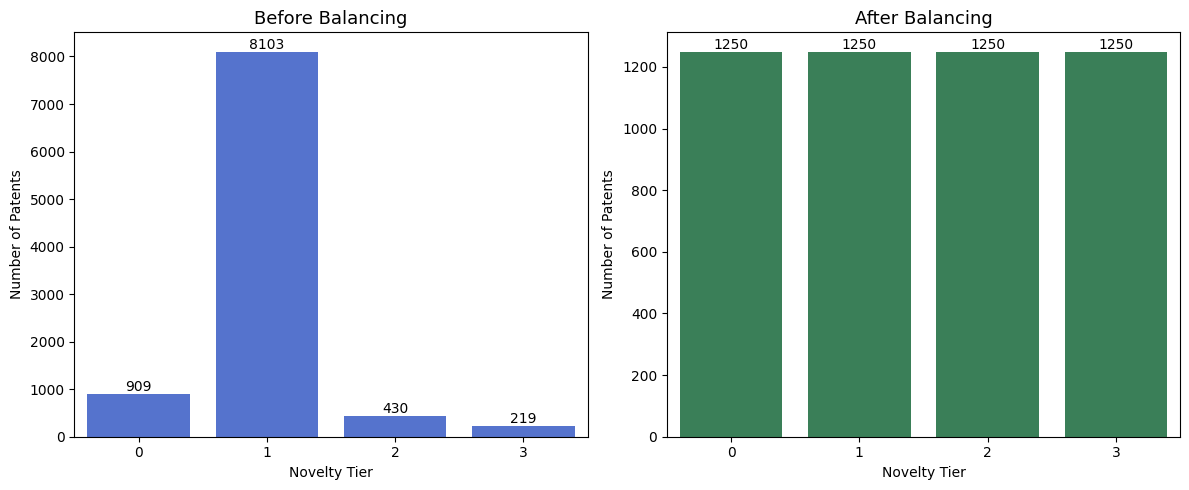

In [38]:
fig, axes = plt.subplots(1, 2, figsize=(12,5))

sns.countplot(
    x=df["novelty tier"],
    ax=axes[0],
    color="royalblue"
)

axes[0].set_title("Before Balancing", fontsize=13)
axes[0].set_xlabel("Novelty Tier")
axes[0].set_ylabel("Number of Patents")

for p in axes[0].patches:
    axes[0].annotate(
        f'{int(p.get_height())}',
        (p.get_x() + p.get_width()/2, p.get_height()),
        ha='center',
        va='bottom',
        fontsize=10
    )


sns.countplot(
    x=df_balanced["novelty tier"],
    ax=axes[1],
    color="seagreen"
)

axes[1].set_title("After Balancing", fontsize=13)
axes[1].set_xlabel("Novelty Tier")
axes[1].set_ylabel("Number of Patents")

for p in axes[1].patches:
    axes[1].annotate(
        f'{int(p.get_height())}',
        (p.get_x() + p.get_width()/2, p.get_height()),
        ha='center',
        va='bottom',
        fontsize=10
    )

plt.tight_layout()
plt.show()


### ii. Average Text Length per Novelty Tier

This visualization shows the average number of words in patent text for each novelty tier.

From the plot, we observe that the average text length increases as the novelty tier increases. Tier 0 patents have the shortest average length, while Tier 3 patents contain the longest descriptions.

This trend suggests that highly novel patents tend to include more detailed explanations, technical descriptions, and implementation details compared to lower novelty patents.


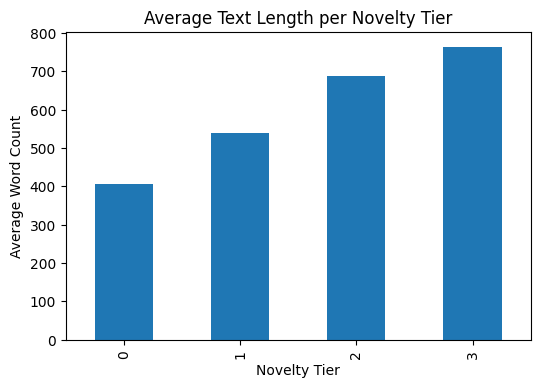

In [39]:
df_balanced["text_length"] = df_balanced["clean_text"].apply(lambda x: len(str(x).split()))

avg_length = df_balanced.groupby("novelty tier")["text_length"].mean()

plt.figure(figsize=(6,4))
avg_length.plot(kind="bar")

plt.title("Average Text Length per Novelty Tier")
plt.xlabel("Novelty Tier")
plt.ylabel("Average Word Count")

plt.show()

### iii. Text Length Variation by Novelty Tier

The boxplot illustrates the variation in text length across different novelty tiers.

The visualization shows that higher novelty tiers not only have longer texts but also greater variability in their lengths. Tier 3 patents exhibit the widest spread and contain several extreme outliers with very large word counts.

This indicates that innovative patents often require extensive descriptions to clearly explain new technologies, system architectures, or implementations.



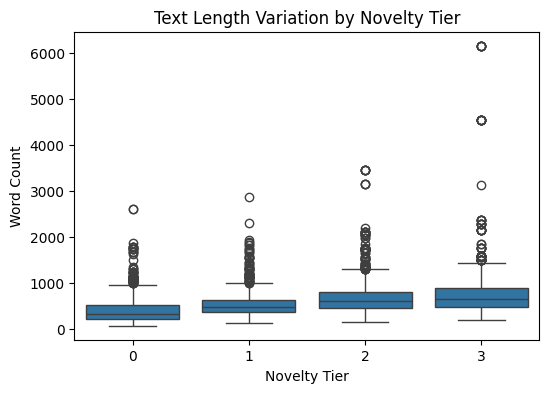

In [40]:
plt.figure(figsize=(6,4))

sns.boxplot(
    x="novelty tier",
    y="text_length",
    data=df_balanced
)

plt.title("Text Length Variation by Novelty Tier")
plt.xlabel("Novelty Tier")
plt.ylabel("Word Count")

plt.show()


### iv. Distribution of Text Length (Word Count)

The histogram represents the distribution of patent text lengths across the dataset.

The distribution is right-skewed, meaning most patents contain a moderate number of words, typically between 300 and 800 words. However, there are a few patents with extremely large word counts, reaching several thousand words.

This pattern is common in technical patent datasets where most documents are moderate in length but a small number contain very detailed technical descriptions.




Text Length Statistics:
count    5000.00000
mean      599.38300
std       431.07374
min        71.00000
25%       362.00000
50%       518.00000
75%       716.00000
max      6149.00000
Name: text_length, dtype: float64


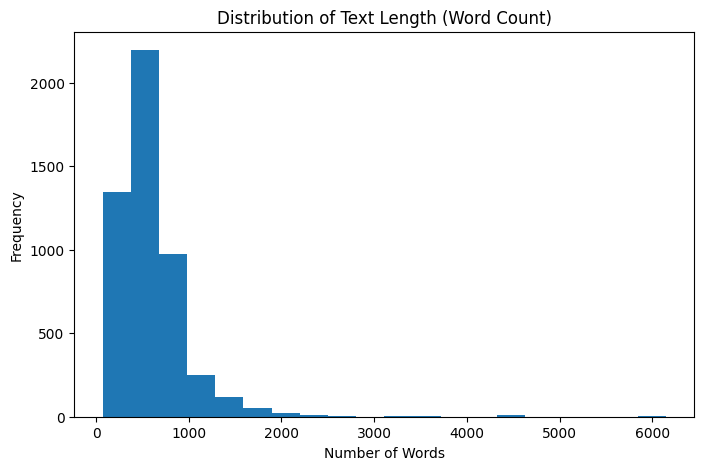

In [41]:
df_balanced["text_length"] = df_balanced["clean_text"].apply(lambda x: len(str(x).split()))

print("\nText Length Statistics:")
print(df_balanced["text_length"].describe())

plt.figure(figsize=(8,5))

plt.hist(df_balanced["text_length"], bins=20)

plt.title("Distribution of Text Length (Word Count)")
plt.xlabel("Number of Words")
plt.ylabel("Frequency")

plt.show()

### v. Top 20 Most Frequent Words in the Patent Dataset

This plot shows the 20 most frequently occurring words in the cleaned patent text.

Words such as **information, signal, control, processor, power, and image** appear most frequently. These terms are commonly used in hardware and electronic system patents, indicating that the dataset largely focuses on digital systems, signal processing, and embedded hardware technologies.

The frequent occurrence of such technical terms confirms that the dataset represents engineering-oriented patent descriptions.



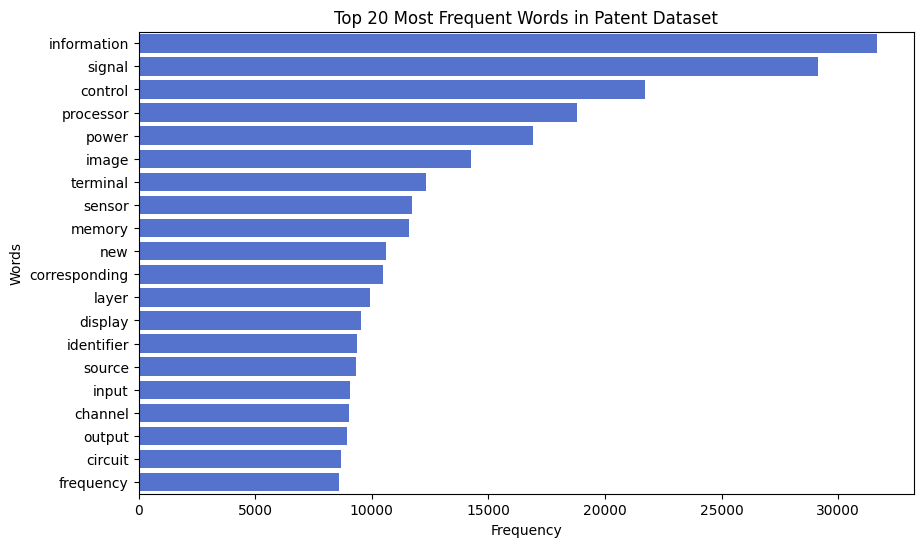

In [42]:
text = " ".join(df_balanced["clean_text"])

words = text.split()

word_counts = Counter(words).most_common(20)

words = [w[0] for w in word_counts]
counts = [w[1] for w in word_counts]

plt.figure(figsize=(10,6))

sns.barplot(x=counts, y=words, color="royalblue")

plt.title("Top 20 Most Frequent Words in Patent Dataset")
plt.xlabel("Frequency")
plt.ylabel("Words")

plt.show()

### vi. Word Cloud of Patent Text

The word cloud provides a visual representation of the most prominent words in the patent dataset.

Words that appear larger in the cloud occur more frequently in the dataset. Prominent terms include **data, control, signal, processor, battery, pack, instruction, and execution**. These words highlight the dominant technical themes within the patents, particularly in computing systems, hardware control mechanisms, and electronic circuit components.

The word cloud helps provide an intuitive overview of the key terminology used throughout the patent descriptions.


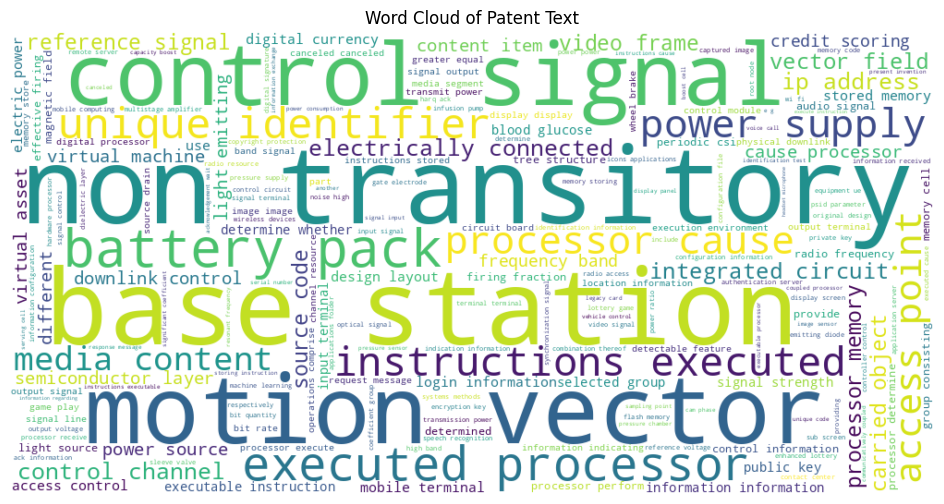

In [43]:
text = " ".join(df_balanced["clean_text"])

wordcloud = WordCloud(
    width=1000,
    height=500,
    background_color="white",
    max_words=200
).generate(text)

plt.figure(figsize=(12,6))

plt.imshow(wordcloud, interpolation="bilinear")

plt.axis("off")

plt.title("Word Cloud of Patent Text")

plt.show()